# resnetppo

This notebook documents an unsupervised/reinforcement learning experiment, including environment setup and model training.

This file keeps the original experimentation style and adds a small structure note for easier navigation.


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision import datasets
#import resnet50
from torchvision.models import resnet18,resnet50,resnet101
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import skimage
import random

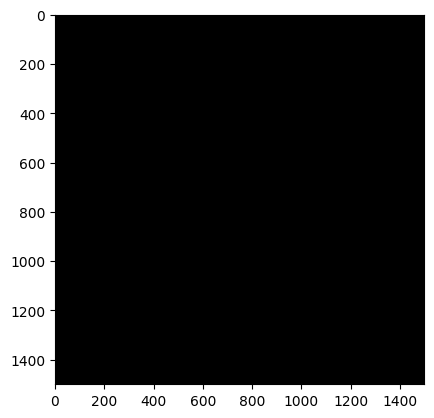

In [10]:
#create images
monkee=skimage.io.imread('/kaggle/input/imagenmonkee/fae6202d-2a8b-40e3-8d05-19f46ba7b537.ce308afc0ee1b59229142849913da8f1.jpeg')
monkee=skimage.transform.resize(monkee,(250,250))
img=monkee
preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
#create 1500x1500 canvas
canvas=np.zeros((1500,1500,3))
x=750-monkee.shape[0]/2
resnetimages=[]
ys=[]
for i in range(3):
    y=random.randint(0,1000)
    canvas[int(y):int(y)+monkee.shape[0],int(x):int(x)+monkee.shape[1]]=monkee
    yinfivesec=y+(1/2)*9.8*5**2
    ys.append(yinfivesec)
    resnetimages.append(preprocess(canvas))
    canvas=np.zeros((1500,1500,3))




plt.imshow(canvas)

In [11]:
modelo = torch.hub.load('pytorch/vision:v0.10.0', 'vgg11', pretrained=True)

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


In [12]:
#from torchsummary import summary
#modelresnet=resnet101(pretrained=True)
#print(modelresnet.layer4)
#

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
torch.set_default_device(device)

Using device: cuda


In [14]:

class game():
  def __init__(self):
    self.x=450

  def reset(self):
    self.x=450
    self.y=0
    self.canvas = np.zeros((1500, 1500,3))
    self.canvas[self.y:self.y+250,self.x:self.x+250]=img
    print(self.canvas.shape)
    #resize image
    self.canvas=preprocess(self.canvas)
    return self.canvas,0,False,{}
  def step(self,action):
    self.canvas=np.zeros((1500,1500,3))
    print(self.y)
    freefall=self.y+(1/2)*9.8*(2)**2
    print("yfuture")
    print(freefall)

    self.y=freefall
    if self.y>1500-250:
      done=True
      return preprocess(self.canvas),1,done,{}
    else:
      done=False
    self.y=int(freefall)
    print()
    self.canvas[self.y:self.y+250,self.x:self.x+250]=img
    #resize image
    stateaf=preprocess(self.canvas)
    reward=self.reward(action)
    info={}
    return stateaf,reward,done,info


  def reward(self,action):
    #print((self.y,action))
    return 100/(1+torch.nn.functional.mse_loss(torch.tensor(action),torch.tensor(self.y)))

In [15]:
class ResBlock(torch.nn.Module):
  def __init__(self,inn,outt,downsample):
    super(ResBlock,self).__init__()
    self.conv1=torch.nn.Conv2d(inn,outt,3,padding=1)
    self.batchnorm1=torch.nn.BatchNorm2d(outt)
    self.relu=torch.nn.ReLU()

    self.downsample = downsample
    self.avgpool=torch.nn.AvgPool2d(2,2)
    if self.downsample or inn != outt:
            self.identity_downsample = nn.Conv2d(inn, outt, kernel_size=1, stride=1)
            self.identity_batchnorm = nn.BatchNorm2d(outt)
    else:
            self.identity_downsample = None
  def forward(self,x):
    residual=self.conv1(x)
    residual=self.batchnorm1(residual)
    residual=self.relu(residual)
    identity = x
    #print("identity shape")
    #print(identity.shape)
    #print("residual shape")
    #print(residual.shape)
    if self.identity_downsample is not None:
        identity = self.identity_downsample(identity)
        #print("identity shape2")
        #print(identity.shape)
        identity = self.identity_batchnorm(identity)

        # Add residual and identity
        output = residual + identity
        output = self.relu(output)
        output = self.avgpool(output)
        return output
    else:
        output = residual + identity
        output = self.relu(output)
        output = self.avgpool(output)
        return output

    return output




In [16]:
class actorr(torch.nn.Module):
    def __init__(self,limit):
        super(actorr,self).__init__()
        self.resBlock1=ResBlock(3,32,True)
        self.resBlock2=ResBlock(32,32,True)
        self.resBlock3=ResBlock(32,64,True)
        self.resBlock4=ResBlock(64,64,True)
        #self.resnet=resnet18(pretrained=False)
        #self.vgg=torch.hub.load('pytorch/vision:v0.10.0', 'vgg11', pretrained=True)

        #self.vgg=torch.nn.Sequential(*list(self.vgg.children())[:-1])
        self.flatten=torch.nn.Flatten()
        self.fcmean=torch.nn.Linear(100,1)
        self.fcvar=torch.nn.Linear(12544,200)
        self.fcvar2=torch.nn.Linear(200,100)
        self.fcvar3=torch.nn.Linear(100,1)
        #self.instancenorm3=torch.nn.RMSNorm((1,200),elementwise_affine=True)
        #self.instancenorm2=torch.nn.RMSNorm((1,100),elementwise_affine=True)
        #self.instancenorm1=torch.nn.RMSNorm((1,200),elementwise_affine=True)
        #self.groupnorm1=torch.nn.GroupNorm(num_groups=32,num_channels=512)
        self.selu1=torch.nn.SELU()
        self.selu2=torch.nn.SELU()
        self.selu3=torch.nn.SELU()
        self.sigmoid=torch.nn.Sigmoid()
        self.limit=limit
        #initialize fc
        #torch.nn.init.xavier_uniform_(self.fcmean.weight)
        #torch.nn.init.xavier_uniform_(self.fcvar.weight)
        #torch.nn.init.xavier_uniform_(self.fcvar2.weight)
        #torch.nn.init.xavier_uniform_(self.fcvar3.weight)
        #remove last fc layer withou
        #self.resnet.fc=torch.nn.Identity()
        #self.vgg.classifier=torch.nn.Identity()


        #for param in self.resnet.parameters():
            #param.requires_grad = False
        #unfreeze with a probability
        #for param in self.resnet.parameters():
            #delta=random.random()
            #if delta<self.limit:
                #param.requires_grad = True
        #self.resnet.layer4.requires_grad_(True)
        #self.resnet.layer3.requires_grad_(True)
        #self.resnet.layer2.requires_grad_(True)
        #self.resnet.layer1.requires_grad_(True)
        #for param in self.vgg.parameters():
            #param.requires_grad = False
        for name, param in self.named_parameters():
          print(f"Parameter: {name} | requires_grad: {param.requires_grad}")



    def forward(self,x):
        x=self.resBlock1(x)
        x=self.resBlock2(x)
        x=self.resBlock3(x)
        x=self.resBlock4(x)
        #x=self.vgg(x)
        #x=self.groupnorm1(x)
        #print("ex sheip")
        #print(x.shape)
        x=self.flatten(x)


        x=self.fcvar(x)
        #x=self.instancenorm1(x)
        #print("shapefif")
        #print(x.shape)
        #dinamic instance
        #x=torch.reshape(x,(-1,1,200))
        #tensorrr=torch.Tensor([])
        #for i in x:
          #print(i.shape)


          #i=self.instancenorm1(i)
          #concat
          #tensorrr=torch.cat((tensorrr,i),0)
        #x=tensorrr

        #x=torch.reshape(x,(-1,200))
        #x=self.selu1(x)
        x=torch.nn.SELU()(x)

        #x=torch.nn.Dropout(0.5)(x)

        #x=tensorr
        x=self.fcvar2(x)
        #x=torch.nn.InstanceNorm1d(x.shape[0])(x)
        #x=self.selu2(x)
        x=torch.nn.SELU()(x)

        #x=torch.nn.Dropout(0.5)(x)
        #x=self.instancenorm2(x)
        #x=self.selu2(x)
        variance=self.fcvar3(x)
        mean=self.fcmean(x)
        x=torch.cat((mean,variance),1)

        #concat the mean and variance
        #x=self.instancenorm3(x)
        #x=self.sigmoid(x)



        x=torch.nn.Sigmoid()(x)
        #x=torch.nn.ReLU6()(x)





        return x
    def act(self,x,eps,deterministic):
        #print("input sheip")
        #print(x.shape)

        x=self.forward(x)
        #print("mean and std")


        #static variance
        variance=x[:,1]+1e-5
        #variance=torch.ones(x.shape[0])
        variance=torch.clamp(variance,min=1e-3,max=1.0*eps)
        variance=torch.reshape(variance,(-1,1))

        #print(x[:,0])
        #print(x[:,1])
        #clampvar

        cov=torch.diag(variance)
        dist=torch.distributions.Normal(x[:,0],variance)
        if deterministic:
            action=x[:,0]*1500
            return action,0,0,action
        action=dist.rsample()
        action=torch.reshape(action,(-1,1))
        #print("action")
        #print(action)


        log_prob=dist.log_prob(action)
        log_prob=log_prob
        actionunscaled=action
        action=action*1500
        #print("log prob")
        #print(log_prob)
        entropy=dist.entropy()
        entropy=torch.mean(entropy)
        #print("entropy")
        #print(entropy)
        log_prob=torch.reshape(log_prob,(-1,1))
        if deterministic:
            print("deterministaaaa")
            action=x[:,0]*1500
            print("action determinista")
            print(action)


        return action,log_prob,entropy,actionunscaled
    def actonlogprob(self,x,eps,deterministic,actions):
      meaandavg=torch.Tensor([])
      #print("input sheip")
      #print(x.shape)
      for i in x:
        i=torch.unsqueeze(i,0)

        i=self.forward(i)
        #print("actionss")
        #print(actions)
        meaandavg=torch.cat((meaandavg,i),0)
      x=meaandavg
      #static variance
      variance=x[:,1]+1e-5
      #x=self.forward(x)
      #variance=torch.ones(x.shape[0])
      variance=torch.clamp(variance,min=1e-3,max=1.0*eps)
      dist=torch.distributions.Normal(x[:,0],variance)
      logprobs=dist.log_prob(actions)
      logprobs=logprobs
      entropy=dist.entropy()
      entropy=torch.mean(entropy)
      #print("logprobs")
      #print(logprobs)
      #print("entropy")
      #print(entropy)
      #print("mean and std")
      #print(x[:,0])
      #print(x[:,1])
      graph=plt.plot(x[:,0].cpu().detach())
      #save
      #remove graph
      plt.savefig('graphmean.png')
      plt.clf()
      #plt.show()
      graph=plt.plot(x[:,1].cpu().detach())
      #save
      plt.savefig('graphstd.png')
      plt.clf()
      #plt.show()



      return logprobs,entropy

class qfunction(torch.nn.Module):
    def __init__(self):
        super(qfunction,self).__init__()
        self.resnet=resnet18(pretrained=True)
        self.vgg=torch.hub.load('pytorch/vision:v0.10.0', 'vgg11', pretrained=True)
        self.vgg=torch.nn.Sequential(*list(self.vgg.children())[:-1])
        self.resnet=torch.nn.Sequential(*list(self.resnet.children())[:-1])
        self.flatten=torch.nn.Flatten()
        self.fc=torch.nn.Linear(512,100)
        self.fc1=torch.nn.Linear(100,10)
        self.fc2=torch.nn.Linear(10,1)


        self.conv1daction=torch.nn.Linear(1,32)
        self.batchnorm=torch.nn.InstanceNorm1d(32)
        self.selu=torch.nn.SELU()
        self.conv2daction=torch.nn.Linear(32,32)
        self.batchnorm2=torch.nn.InstanceNorm1d(32)
        self.convidentityaction=torch.nn.Linear(1,32)
        #initialize fc
        torch.nn.init.xavier_uniform_(self.fc.weight)
    def forward(self,x):
        x=self.resnet(x)
        #x=self.vgg(x)
        x=self.flatten(x)
        x=self.fc(x)
        x=torch.nn.SELU()(x)
        x=self.fc1(x)
        x=torch.nn.SELU()(x)
        x=self.fc2(x)
        return x

In [17]:
from collections import deque

In [18]:
class train():
  def __init__(self,env,t,gamma,actor,critic,epochs,initial_eps,decay,deterministic,lambdad,epsilon,limit):
    self.epsilon=epsilon
    self.env=env
    self.t=t
    self.gamma=gamma
    self.policy_net=actor(limit)
    self.critic_net=critic()
    self.optimizeractor=torch.optim.Adam(self.policy_net.parameters(),lr=0.00006,weight_decay=0.4)
    self.optimizercritic=torch.optim.Adam(self.critic_net.parameters(),lr=0.004,weight_decay=0.2)
    #clip grad
    #torch.nn.utils.clip_grad_value_(self.policy_net.parameters(), clip_value=1.0)
    #torch.nn.utils.clip_grad_value_(self.critic_net.parameters(), clip_value=1.0)
    self.epochs=epochs
    self.acc_rewards=[]
    #self.policy_net.resnet.requires_grad_(False)
    self.critic_net.resnet.requires_grad_(False)
    #self.policy_net.vgg.requires_grad_(False)
    self.critic_net.vgg.requires_grad_(False)

    self.eps=initial_eps
    self.decay=decay
    self.avgs=[]
    self.deterministic=deterministic
    self.lmbda=lambdad

  def millonariosonacional(self,states):
    al=random.random()
    if al<self.eps:
      print("millonarios")
      #create batch of random variables
      meaandesv = torch.rand((states.shape[0], 2))
      mean = meaandesv[:, 0]
      stddev = torch.clamp(meaandesv[:, 1], min=1e-3, max=1.0)
      cov_matrix = torch.diag(stddev**2)
      dist=torch.distributions.MultivariateNormal(mean,cov_matrix)
      action=dist.rsample()
      log_prob=dist.log_prob(action)

      action=action*1500

      print(action,log_prob)
      return action,log_prob

    else:
      print("nacional")
      action,lobg_prob=self.policy_net.act(states)
    return action,lobg_prob


  def runtimesteps(self,t):
    ts=t
    initial_arr=deque(maxlen=ts+100)
    rewards=deque(maxlen=ts+100)
    dones=deque(maxlen=ts+100)
    rotwarr=deque(maxlen=ts+100)
    actions=deque(maxlen=ts+100)
    log_probs=deque(maxlen=ts+100)
    advantages=torch.Tensor([])
    gaereturnss=torch.Tensor([])



    while t>=0:
      rotwsub=deque(maxlen=ts+100)
      initial_intern=deque(maxlen=ts+100)
      dones_intern=deque(maxlen=ts+100)
      initial_state,reward,done,info=self.env.reset()
      acc_reward=0
      trayectories=0


      while not done:
        #print("la forma")
        #print(initial_state.shape)
        action,log_prob,_,actionunscaled=self.policy_net.act(initial_state.unsqueeze(0).to("cuda"),self.eps,self.deterministic)
        action=action
        actions.append(actionunscaled)
        log_prob=log_prob
        #action=torch.sigmoid(action)
        #action=action*1500
        state,reward,done,info=self.env.step(action)
        initial_intern.append(initial_state.detach())


        #print(reward)
        rewards.append(reward)
        dones_intern.append(done)
        log_probs.append(log_prob.detach())
        rotwsub.append(reward)
        t-=1
        initial_state=state
        acc_reward+=reward
      #advantages=advantages+self.gae(initial_intern,rotwsub,dones_intern)
      gaeadvantages,gaereturns=self.gae(initial_intern,rotwsub,dones_intern)
      advantages=torch.cat((advantages,gaeadvantages),0)
      gaereturnss=torch.cat((gaereturnss,gaereturns),0)
      dones=dones+dones_intern
      initial_arr=initial_arr+initial_intern
      self.acc_rewards.append(acc_reward)
      trayectories+=1

      if len(self.acc_rewards)>=5:

        batchacc=self.acc_rewards[-5:]
        avg=sum(batchacc)/len(batchacc)
        self.avgs.append(avg)
        print(avg)
        #plt.plot(self.avgs)
        #plt.show()

      rotwarr+=self.rewontheway(rotwsub)
    return initial_arr,rewards,actions,dones,rotwarr,log_probs,advantages,gaereturnss,trayectories
  def rewontheway(self,rotwsub):
    rotw=torch.Tensor([0])
    output=deque(maxlen=len(rotwsub))
    print(rotwsub)
    rotwsub.reverse()
    print(rotwsub)
    for z,i in enumerate(rotwsub):
      rotw=i+rotw.clone()*self.gamma**(len(rotwsub)-z)

      output.insert(0,rotw)
    return output
  def train(self):
    initial_states,rewards,actions,dones,rotwar,log_pro,advantages,gaereturnss,trayectories=self.runtimesteps(self.t)
    tensorin=torch.stack(tuple(initial_states)).to("cuda")
    rotwarr=torch.stack(tuple(rotwar)).to("cuda")
    log_probs=torch.Tensor(log_pro).to("cuda")
    #print("log_probs1")
    #print(log_probs)
    log_probs=torch.reshape(log_probs,(-1,1))
    #print("log_probs2")
    #print(log_probs)
    actions=torch.Tensor(actions).to("cuda")
    tensorin=tensorin



    for i in range(self.epochs):
      clear_output()

      #1
      criticeval=self.critic_net(tensorin)
      advantagee=advantages
      #2
      #advantagee=((advantage-advantage.mean())/(advantage.std()+1e-5))


      logprob,entropy=self.policy_net.actonlogprob(tensorin,self.eps,self.deterministic,actions)
      logprob=torch.reshape(logprob,(-1,1))
      #print("logprob")
      #print(logprob)
      #print("log_probs")
      #print(log_probs)
      #action=torch.sigmoid(action)
      #action=action*1500
      ratio=torch.exp(logprob-log_probs)
      #print("ratio")
      #print(ratio.shape)
      #ratio=torch.clamp(ratio,1-self.epsilon,1+self.epsilon)
      #print("ratio")
      #print(ratio)
      #print("advantagee")
      #print(advantagee)
      surr1=ratio*advantagee
      surr2=(torch.clamp(ratio,1-self.epsilon,1+self.epsilon)*advantagee)
      loss1=(-torch.min(surr1,surr2).sum())/len(initial_states)
      #print("loss1")
      #print(loss1)
      #print("lossss 1")
      #print(loss1)
      #print gradients

      loss2=F.mse_loss(criticeval,gaereturnss)
      #print("loss2")
      #print(loss2)
      #print("entrphyss")
      #print(entropy)



      finalloss=1*loss1+0.5*loss2-0.1*entropy
      #print("finalloss")
      #print(finalloss)
      self.optimizeractor.zero_grad()
      self.optimizercritic.zero_grad()
      finalloss.backward(retain_graph=True)
      #clip grad norm
      torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), max_norm=1.0)
      torch.nn.utils.clip_grad_norm_(self.critic_net.parameters(), max_norm=10.0)
      self.optimizeractor.step()
      self.optimizercritic.step()
      print("Actor Gradients:")
      for name, param in self.policy_net.named_parameters():
            if param.grad is not None:
                print(f"Parameter: {name} | Grad Norm: {param.grad.norm()}")
      print("Critic Gradients:")
      for name, param in self.critic_net.named_parameters():
            if param.grad is not None:
                print(f"Parameter: {name} | Grad Norm: {param.grad.norm()}")
    self.eps=self.eps*self.decay
    print("epsilon")
    print(self.eps)
    if self.eps<0.01:
      self.eps=0.01

      print({"loss1":loss1,"loss2":loss2,"actions":actions})
  def gae(self,states,rewards,done):
    returns = deque(maxlen=300)
    gae = 0
    print("zs")
    states=torch.stack(tuple(states))
    print(rewards)
    print(done)
    values=self.critic_net(states.to("cuda")).detach()

    #concat 0 tensor
    values=torch.cat((values,torch.Tensor([[0]])),0)
    print(values.shape)
    for i in reversed(range(len(rewards))):
        delta = rewards[i] + self.gamma * values[i + 1,0]  - values[i,0]
        gae = delta + self.gamma * self.lmbda *  gae
        returns.insert(0, gae.detach() + values[i].detach())

    adv = returns
    adv = torch.stack(tuple(adv))
    #print("adv")
    #print(adv)
    gaereturns=adv-values[:-1]
    #print("gaereturns")
    #print(gaereturns)
    return ((adv - adv.mean()) / (adv.std() + 1e-10)),gaereturns




In [19]:


torch.set_default_tensor_type('torch.cuda.FloatTensor')

from IPython.display import clear_output






torch.autograd.set_detect_anomaly(True)

trains=train(game(),100,0.99,actorr,qfunction,5,1,0.999,False,0.95,0.5,0.1)
pipeline=400
for i in range(pipeline):
  clear_output(wait=True)
  trains.train()

KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

{-pOq,r->(sY-t),-s} imp -rYq

*   List item

*   List item
*   List item


*   List item


{-( ( (-pOq) Y (r->(sY-t)) Y (-s) ) -> (-rYq)) }
{( (-pOq) Y (r->(sY-t)) Y (-s) ) Y -(-rYq) }
{( (-pOq) Y (r->(sY-t)) Y (-s) ) , -(-rYq) }
{ (-pOq) , (r->(sY-t)) , (-s)  , (rO-q) }
{ (-pOq) , (-rO(sY-t)) , (-s)  , (rO-q) }
{ (-pOq) , -r , (-s)  , (rO-q) } { (-pOq) , (sY-t) , (-s)  , (rO-q) }
 { (-pOq) , -r , (-s)  , r } { (-pOq) , -r , (-s)  ,-q }



 { (-p) , -r , (-s)  ,-q }                               { (-pOq) , s,-t , (-s)  , (rO-q) }
                                                 x



In [ ]:
pipeline=1000
trains.deterministic=True
print(trains.deterministic)
for i in range(pipeline):
  trains.train()

In [ ]:
#get all asci code
import string

ascilist=list("abcdefghijkl")

image="eldiablo.png"
imgtonumpy=skimage.io.imread(image)
#do a mean between all the channels
imgtonumpy=np.mean(imgtonumpy,axis=2)
#normalize
imgtonumpy=imgtonumpy/255
#resize
imgtonumpy=skimage.transform.resize(imgtonumpy,(50,100))
shape=imgtonumpy.shape
flatten=np.reshape(imgtonumpy,(-1))
toascii=""
for i in range(len(flatten)):
  if i%(shape[1])== 0:
    print(shape[1])
    toascii+="\n"


  toascii+=ascilist[int(flatten[i]*(len(ascilist)-1))]

print(toascii)


satisfacible

{-(p->( (-pOq ) ->q  ) )}
{p, -( (-pOq ) ->q  ) )}
{p, -( -(-pOq ) O q  ) )}
{p, (-pOq ) Y -q   }
{p, (-pOq ) , q   }
{p, -p,q},{

{  (-pOq),(  q-> ( (-rY-p) Y (pOr) ) )  }
{  (-pOq),(  -q O ( (-rY-p) Y (pOr) ) )  }

pY(-qO-p)
{p,-qO-p}
{p,-q} {p,-p}
   .      x

(pOq)Y(-pO-q)
{pOq,-pO-q}
{p,-pO-q} {q,-pO-q}
{p,-p} {p,-q} {q,-p} {q,-q}
  x       o     o      x


{pOq,-pY-q}
{p,-pY-q} {q,-pY-q}
{p,-p,-q} {q,-p,-q}
    x       x


{p->q,q->p}
{p

In [ ]:
#test layernorm on vector
vector=torch.Tensor([1,2,3])
vector=torch.reshape(vector,(1,1,-1))
layernorm=torch.nn.LayerNorm((1,3))
result=layernorm(vector)
print(result)